### Transformations in OpenCV

OpenCV provides powerful tools for transforming images — such as translation, rotation, scaling, and affine transformations — which are essential in many computer vision tasks.

In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [50]:
image = cv2.imread("asserts/giraffe-Kenya.png")

(np.float64(-0.5), np.float64(1066.5), np.float64(1599.5), np.float64(-0.5))

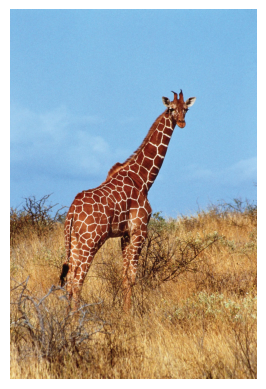

In [51]:
image_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis("off")

In [52]:
image_rgb.shape

(1600, 1067, 3)

In [53]:
rows,cols,_ = image_rgb.shape

### Perspective Transformation in OpenCV

Perspective Transformation is a type of geometric transformation that maps a quadrilateral to another quadrilateral, allowing for the simulation of viewing the image from a different angle or correcting distortion due to camera perspective.

* Unlike Affine Transformations, which preserve parallel lines, Perspective Transformations can handle the effect of depth — meaning straight lines can converge (like in a photo of a road).

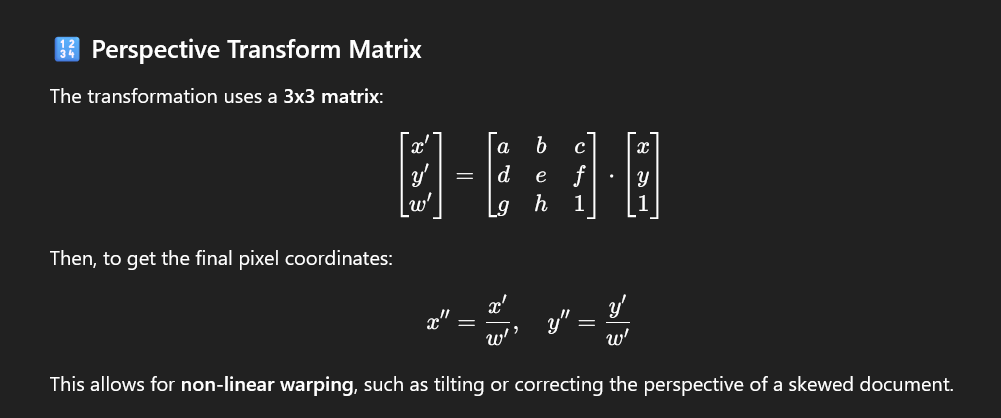

In [54]:
input_points = np.float32([[50,50],[cols-50,50],[50,rows-50],[cols-50,rows-50]])
output_points = np.float32([[10,100],[cols-100,50],[100,rows-10],[cols-50,rows-100]])

''''
transformation matrix for perspective transformation
a,b,c
d,e,f
g,h,i

a,b,c are responsible for horizontal scaling,rotation and translation
d,e,f are responsible for vertical scaling,rotation and translation
g,h,i are responsible for Perspective components that account for depth and skew
'''
M = cv2.getPerspectiveTransform(input_points,output_points)
print(M)

[[ 1.02287821e+00  6.29847356e-02 -4.42634568e+01]
 [-5.02940991e-02  1.04090741e+00  5.07662367e+01]
 [ 3.13145264e-05  2.80659423e-05  1.00000000e+00]]


In [57]:
perspective_image = cv2.warpPerspective(image_rgb,M,(cols,rows))

(np.float64(-0.5), np.float64(1066.5), np.float64(1599.5), np.float64(-0.5))

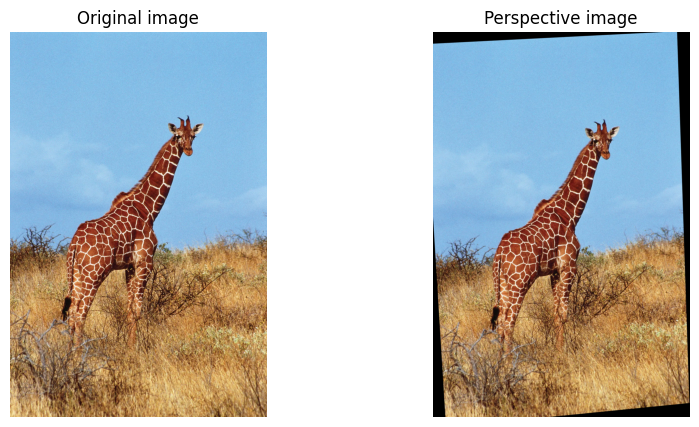

In [58]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original image")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(perspective_image)
plt.title("Perspective image")
plt.axis("off")


### Affine Transformation

Preserves collinearity and ratios of distances. It requires three points from the input and output images.

Formula:

`dst(x,y)=A⋅src(x,y)+b`

Where AA is a 2x2 matrix (rotation, scale, shear), and bb is translation.

(np.float64(-0.5), np.float64(1066.5), np.float64(1599.5), np.float64(-0.5))

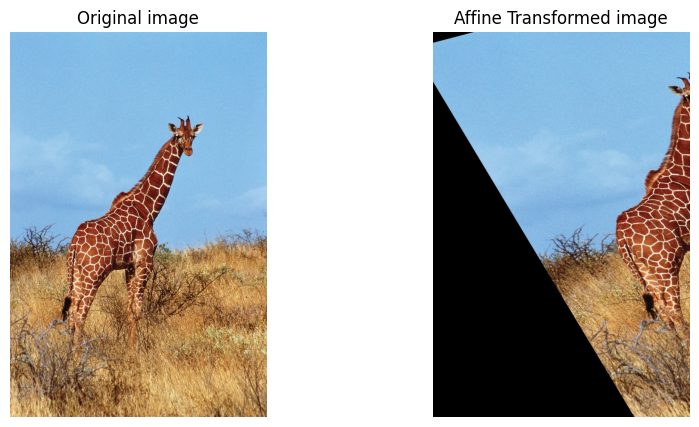

In [64]:
input_pts = np.float32([[50,50],[200,50],[50,200]])
output_pts = np.float32([[10,100],[200,50],[100,250]])


N = cv2.getAffineTransform(input_pts,output_pts)

affine_image = cv2.warpAffine(image_rgb,N,(cols,rows)) 

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original image")
plt.axis("off")
 

plt.subplot(1,2,2)
plt.imshow(affine_image)
plt.title("Affine Transformed image") 
plt.axis("off")

### Rotation

Rotates and optionally scales the image about a specific point.

(np.float64(-0.5), np.float64(1066.5), np.float64(1599.5), np.float64(-0.5))

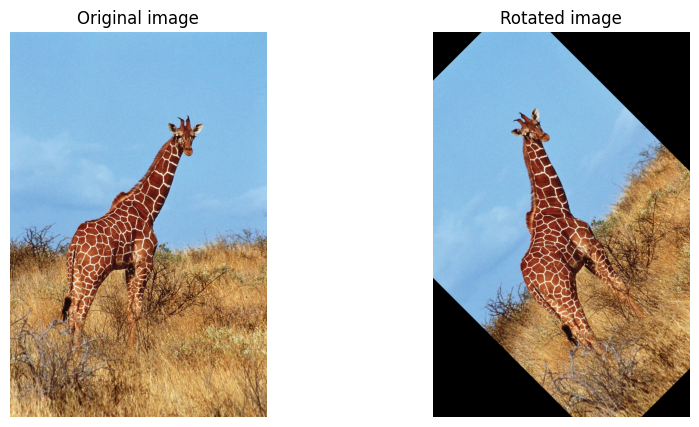

In [68]:
angle = 45
center = (cols//2,rows//2)
scale=1.0

N = cv2.getRotationMatrix2D(center,angle,scale)

rotated_image = cv2.warpAffine(image_rgb,N,(cols,rows))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original image")
plt.axis("off")
 

plt.subplot(1,2,2)
plt.imshow(rotated_image)
plt.title("Rotated image") 
plt.axis("off")

### Shear Transformation in OpenCV

Shearing is a geometric transformation that slants the shape of an image along the X or Y axis — like pulling the image sideways or vertically.

It preserves parallel lines but changes angles and lengths

➤ Horizontal Shear:

\begin{bmatrix}
1 & sh_x & tx \\
0 & 1 & 0
\end{bmatrix}

➤ Vertical Shear:
\begin{bmatrix}
1 & 0 & 0 \\
sh_y & 1 & 0
\end{bmatrix}

    sh_x: Shear factor along the X-axis

    sh_y: Shear factor along the Y-axis

(np.float64(-0.5), np.float64(1866.5), np.float64(1599.5), np.float64(-0.5))

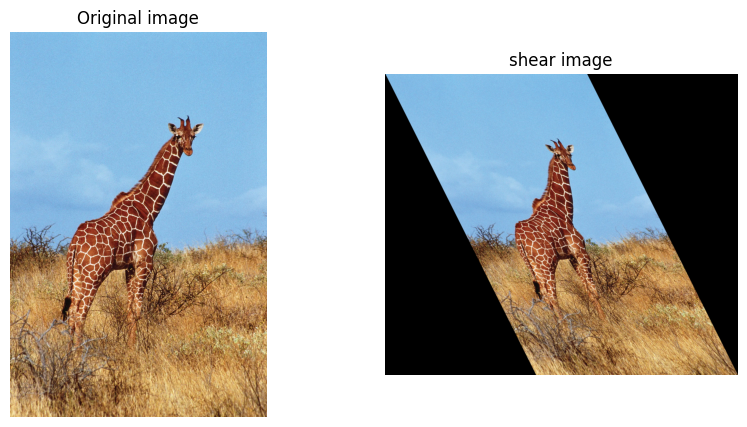

In [74]:
shear_x,shear_y = 0.5,0

N = np.float32([[1,shear_x,0],
            [shear_y,1,0]])

rotated_image = cv2.warpAffine(image_rgb,N,(cols+int(shear_x*rows),rows))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original image")
plt.axis("off")
 

plt.subplot(1,2,2)
plt.imshow(rotated_image)
plt.title("shear image") 
plt.axis("off")

### Translation
Shifts the image along the X and Y axes.


✅ Formula:


\begin{bmatrix}
1 & 0 & tx \\
0 & 1 & ty
\end{bmatrix}




    tx: Shift along the X-axis

    ty: Shift along the Y-axis

(np.float64(-0.5), np.float64(1066.5), np.float64(1599.5), np.float64(-0.5))

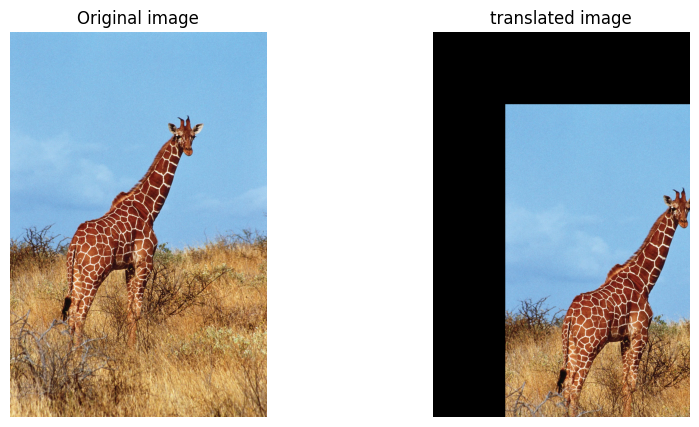

In [77]:
tx,ty = 300,300

N = np.float32([[1,0,tx],
            [0,1,ty]])

translated_image = cv2.warpAffine(image_rgb,N,(cols,rows))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original image")
plt.axis("off")
 

plt.subplot(1,2,2)
plt.imshow(translated_image)
plt.title("translated image") 
plt.axis("off")